In [1]:
# Brian Loch (4/26/2026)
# Packages
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

In [2]:
def predict_type(model, X, threshold=0.28):
    '''wrapper for entire prediction method that includes seperate threshold for ensuring that num types is either 1 or 2'''
    # later add extra func to handle list inputs (for user compatability)

    # Get raw probabilities (shape: n_samples, 18_types)
    probs = np.array([p[:, 1] for p in model.predict_proba(X)]).T

    # Find the index of the highest and second-highest prob for every row
    top_2_indices = np.argsort(probs, axis=1)[:, -2:]

    # Force the #1 choice to 1
    y_pred_constrained = np.zeros_like(probs)
    for i in range(len(y_pred_constrained)):
        # Top choice
        y_pred_constrained[i, top_2_indices[i, -1]] = 1 
        
        # Force the #2 choice ONLY if it's strong
        if probs[i, top_2_indices[i, -2]] > threshold:
            y_pred_constrained[i, top_2_indices[i, -2]] = 1 
    
    return y_pred_constrained

def calc_acc(y_pred, y_test):
    accuracy = accuracy_score(y_test, y_pred)
    pred_counts = y_pred.sum(axis=1)
    return accuracy

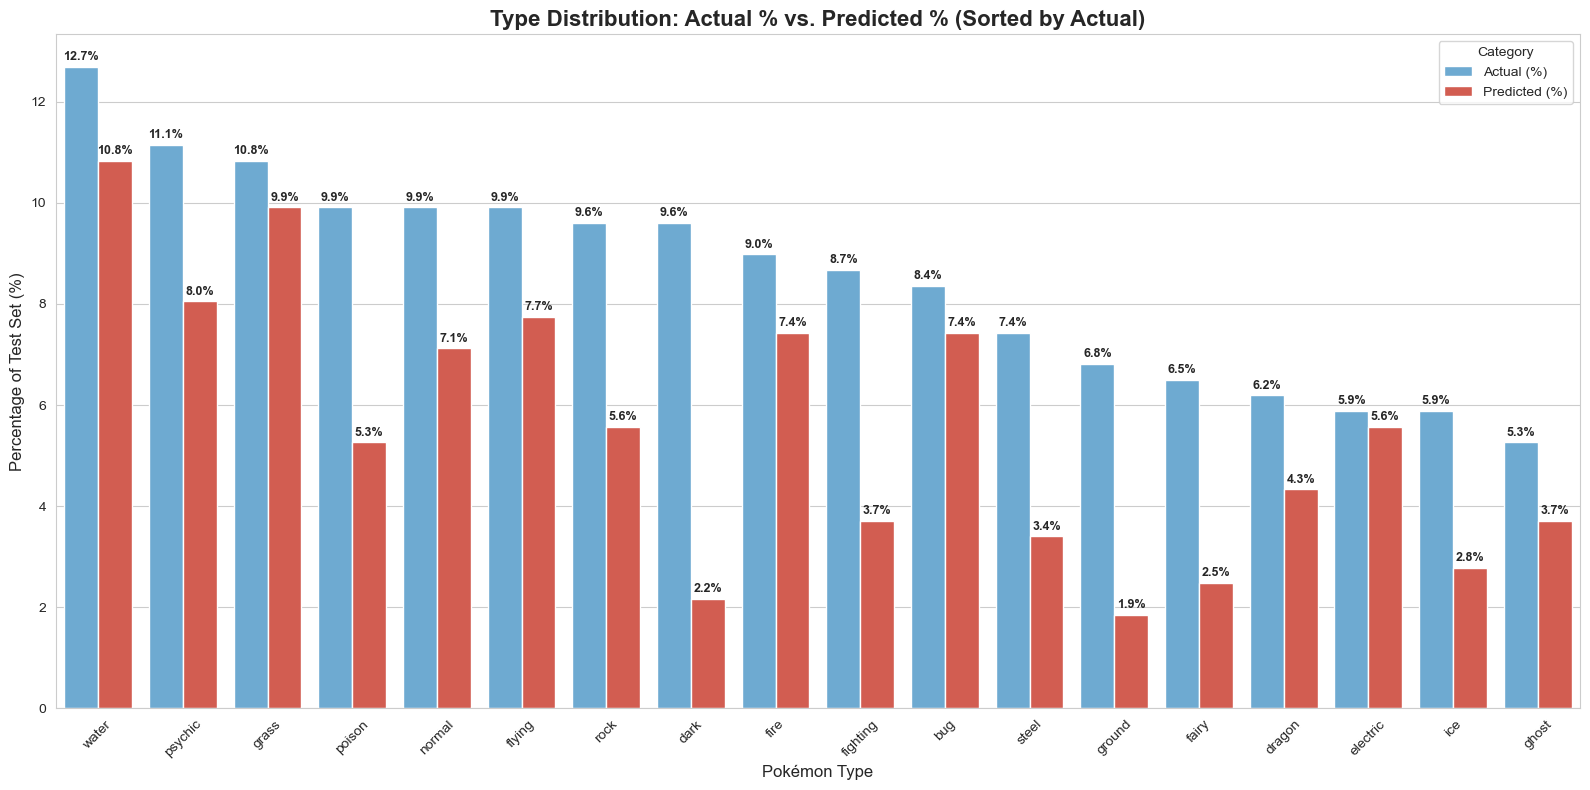

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Sum the occurrences
actual_counts = Y_test.sum()
predicted_counts = pd.Series(Y_pred.sum(axis=0), index=Y_test.columns)

# 2. Calculate Percentages
# We divide by the total number of Pokemon in the test set
total_test_pkmn = len(Y_test)
actual_pct = (actual_counts / total_test_pkmn) * 100
predicted_pct = (predicted_counts / total_test_pkmn) * 100

# 3. Build the comparison DataFrame
comparison_df = pd.DataFrame({
    'Type': [col.replace('type_', '') for col in actual_counts.index],
    'Actual (%)': actual_pct.values,
    'Predicted (%)': predicted_pct.values
})

# 4. SORT by Actual Percentage (Highest to Lowest)
comparison_df = comparison_df.sort_values(by='Actual (%)', ascending=False)
sorted_type_order = comparison_df['Type'].tolist()

# 5. Melt for Seaborn
melted_df = comparison_df.melt(id_vars='Type', var_name='Category', value_name='Percentage')

# 6. Create the grouped bar chart
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=melted_df, 
    x='Type', 
    y='Percentage', 
    hue='Category', 
    order=sorted_type_order,
    palette=['#5DADE2', '#E74C3C']
)

# 7. Formatting
plt.title('Type Distribution: Actual % vs. Predicted % (Sorted by Actual)', fontsize=16, fontweight='bold')
plt.xlabel('Pokémon Type', fontsize=12)
plt.ylabel('Percentage of Test Set (%)', fontsize=12)
plt.xticks(rotation=45)

# Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 7), 
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.legend(title='Category', loc='upper right')
plt.tight_layout()
plt.show()